# Task 2: Bayesian Change Point Modeling and Insight Generation

## Objective

This notebook applies Bayesian change point detection to Brent crude oil
prices to identify structural breaks, quantify changes in market behaviour,
and compare detected change dates with major geopolitical, economic, and
OPEC-related events.

The analysis includes:

- Data preparation and exploratory analysis
- Daily log-return calculation
- Bayesian change point modeling in PyMC
- MCMC sampling and convergence diagnostics
- Posterior interpretation
- Event association
- Quantification of price changes before and after the detected break

In [60]:
from pathlib import Path
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

warnings.filterwarnings("ignore")

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version: 6.1.0
ArviZ version: 1.2.0


In [61]:
PROJECT_ROOT = Path.cwd().parent

PRICE_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "BrentOilPrices.csv"
)

EVENT_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "events"
    / "key_oil_market_events.csv"
)

FIGURES_PATH = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

print("Price data exists:", PRICE_DATA_PATH.exists())
print("Event data exists:", EVENT_DATA_PATH.exists())

Price data exists: True
Event data exists: True


In [62]:
prices = pd.read_csv(PRICE_DATA_PATH)
events = pd.read_csv(EVENT_DATA_PATH)

print("Raw Brent price data:")
display(prices.head())

print("\nHistorical event data:")
display(events.head())

Raw Brent price data:


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63



Historical event data:


,event_date,event_name,event_category,event_description,expected_market_channel,source_organization
0,1990-08-02,Iraq invades Kuwait,Geopolitical conflict,Iraq invaded Kuwait and disrupted oil producti...,Negative supply shock and upward price pressure,U.S. Energy Information Administration
1,1991-01-17,Operation Desert Storm begins,Geopolitical conflict,Coalition military operations began during the...,Supply uncertainty and elevated geopolitical risk,U.S. Energy Information Administration
2,1997-07-02,Asian financial crisis begins,Economic shock,Thailand abandoned its fixed exchange rate and...,Reduced regional economic activity and oil demand,International Monetary Fund
3,2001-09-11,September 11 attacks,Geopolitical shock,Terrorist attacks in the United States created...,Lower aviation demand and increased uncertainty,U.S. Energy Information Administration
4,2003-03-20,Iraq War begins,Geopolitical conflict,Military operations began in Iraq,Supply disruption fears and geopolitical risk,U.S. Energy Information Administration


In [63]:
print("Dataset shape:", prices.shape)

print("\nColumn types:")
print(prices.dtypes)

print("\nMissing values:")
print(prices.isna().sum())

print("\nDuplicate rows:")
print(prices.duplicated().sum())

Dataset shape: (9011, 2)

Column types:
Date         str
Price    float64
dtype: object

Missing values:
Date     0
Price    0
dtype: int64

Duplicate rows:
0


In [64]:
prices["Date"] = pd.to_datetime(
    prices["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce",
)

prices["Price"] = pd.to_numeric(
    prices["Price"],
    errors="coerce",
)

prices = (
    prices
    .dropna(subset=["Date", "Price"])
    .drop_duplicates(subset=["Date"])
    .sort_values("Date")
    .reset_index(drop=True)
)

events["event_date"] = pd.to_datetime(
    events["event_date"],
    errors="coerce",
)

print("Cleaned dataset shape:", prices.shape)
print("Start date:", prices["Date"].min())
print("End date:", prices["Date"].max())
print("Missing values after cleaning:")
print(prices.isna().sum())

Cleaned dataset shape: (9011, 2)
Start date: 1987-05-20 00:00:00
End date: 2022-11-14 00:00:00
Missing values after cleaning:
Date     0
Price    0
dtype: int64


In [65]:
prices["Log_Price"] = np.log(prices["Price"])
prices["Log_Return"] = prices["Log_Price"].diff()

display(
    prices[
        [
            "Date",
            "Price",
            "Log_Price",
            "Log_Return",
        ]
    ].head()
)

,Date,Price,Log_Price,Log_Return
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


In [66]:
prices["Rolling_30D_Volatility"] = (
    prices["Log_Return"]
    .rolling(window=30)
    .std()
)

display(
    prices[
        [
            "Date",
            "Price",
            "Log_Return",
            "Rolling_30D_Volatility",
        ]
    ].tail()
)

,Date,Price,Log_Return,Rolling_30D_Volatility
9006,2022-11-08,96.85,-0.030706,0.019762
9007,2022-11-09,93.05,-0.040026,0.020075
9008,2022-11-10,94.25,0.012814,0.020176
9009,2022-11-11,96.37,0.022244,0.020463
9010,2022-11-14,93.59,-0.029271,0.021001


In [67]:
prepared_data_path = (
    PROCESSED_DATA_PATH
    / "brent_prices_prepared.csv"
)

prices.to_csv(
    prepared_data_path,
    index=False,
)

print(f"Prepared dataset saved to: {prepared_data_path}")
print(f"Rows saved: {len(prices):,}")

Prepared dataset saved to: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 10\brent-oil-change-point-analysis\data\processed\brent_prices_prepared.csv
Rows saved: 9,011


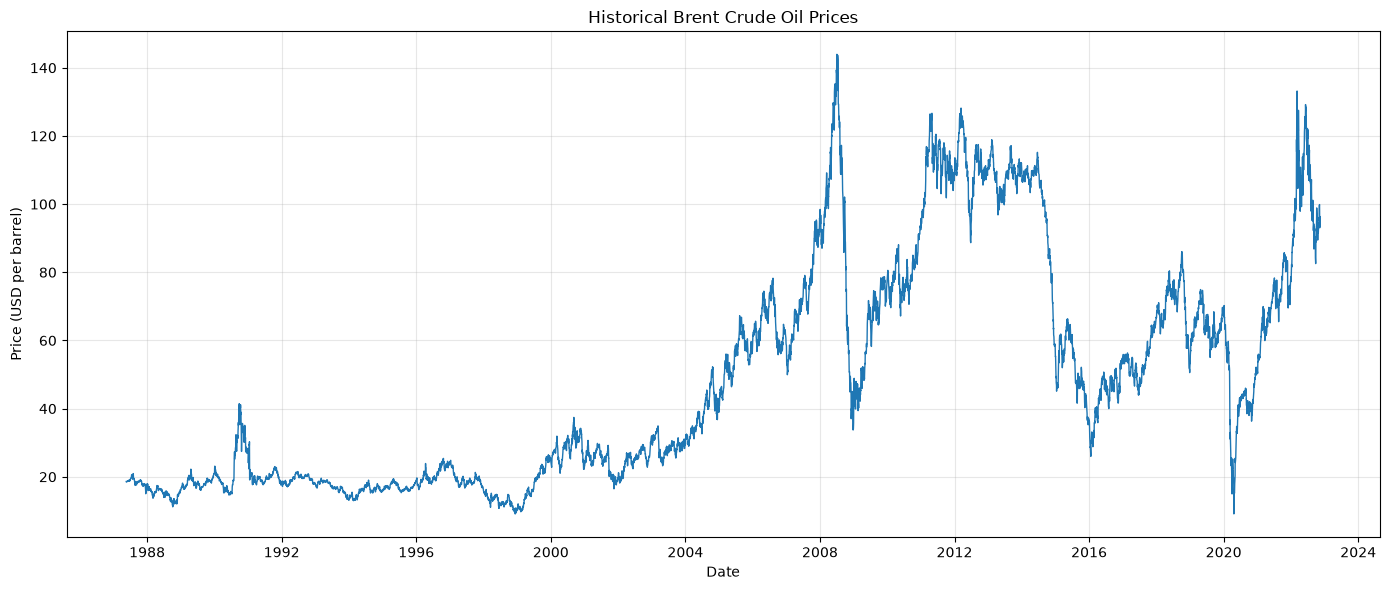

In [68]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    prices["Date"],
    prices["Price"],
    linewidth=1,
)

ax.set_title("Historical Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD per barrel)")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_raw_brent_prices.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Raw Price Series Interpretation

The Brent price series exhibits substantial long-term variation, including
sustained increases, sharp declines, recoveries, and major market shocks.

Important visible periods include:

- The price increase associated with the 1990–1991 Gulf crisis
- Strong growth during the mid-2000s
- The 2008 price peak and subsequent global financial crisis decline
- Elevated prices during 2011–2014
- The major decline beginning in 2014
- The extreme market disruption during 2020
- The rapid recovery during 2021–2022

The changing level of the series suggests that one constant mean is unlikely
to describe the entire historical period. This supports the use of change
point analysis to estimate when the underlying price regime changed.

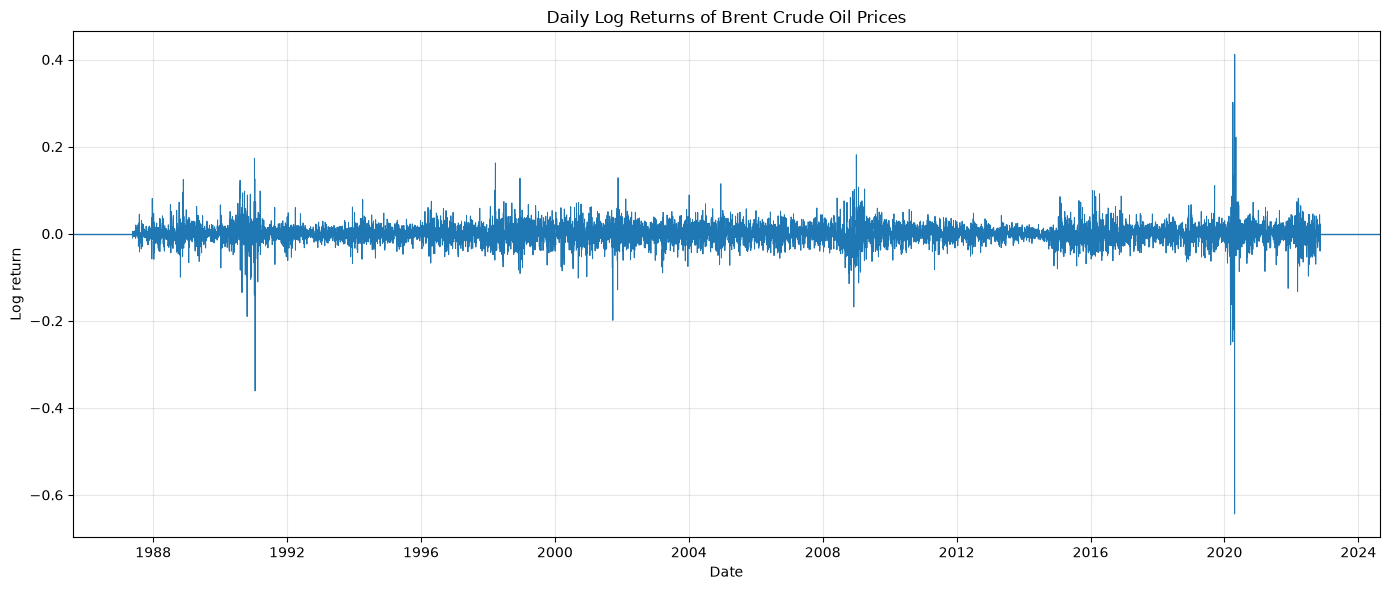

In [69]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    prices["Date"],
    prices["Log_Return"],
    linewidth=0.7,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title("Daily Log Returns of Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_brent_log_returns.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

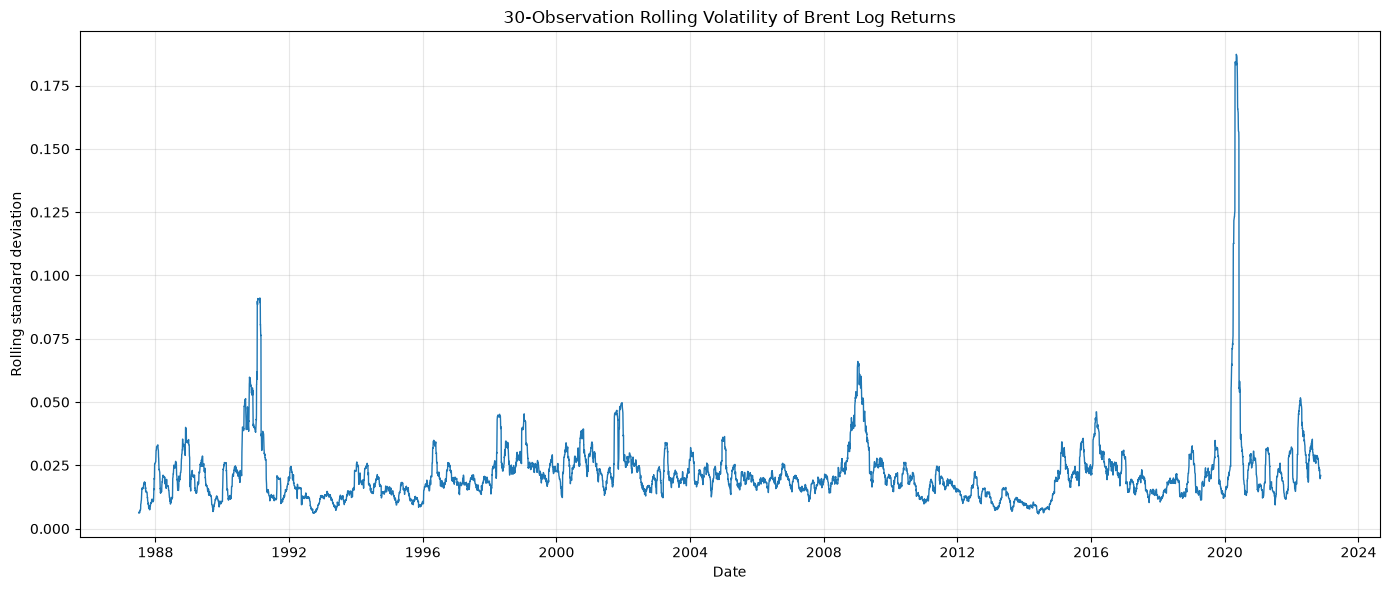

In [70]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    prices["Date"],
    prices["Rolling_30D_Volatility"],
    linewidth=1,
)

ax.set_title(
    "30-Observation Rolling Volatility of Brent Log Returns"
)

ax.set_xlabel("Date")
ax.set_ylabel("Rolling standard deviation")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_rolling_volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Log Return and Volatility Interpretation

Daily log returns fluctuate around zero more consistently than the raw price
series, making them more suitable for examining proportional daily price
movements.

However, the size of the return fluctuations changes considerably over time.
Periods containing repeated large positive and negative returns demonstrate
volatility clustering. The rolling-volatility plot shows particularly strong
volatility around major market disruptions, including the Gulf crisis, the
2008 financial crisis, and the COVID-19 shock in 2020.

These findings suggest that the Brent oil market contains both changing price
levels and changing volatility regimes. The first Bayesian model will focus
on detecting a change in the mean level, while changes in variance may be
considered as an extension.

In [71]:
monthly_prices = (
    prices
    .set_index("Date")["Price"]
    .resample("ME")
    .mean()
    .dropna()
    .reset_index()
)

monthly_prices = monthly_prices.rename(
    columns={"Price": "Monthly_Average_Price"}
)

print("Number of monthly observations:", len(monthly_prices))
display(monthly_prices.head())
display(monthly_prices.tail())

Number of monthly observations: 427


,Date,Monthly_Average_Price
0,1987-05-31,18.580000
1,1987-06-30,18.860476
2,1987-07-31,19.856522
3,1987-08-31,18.979524
4,1987-09-30,18.313182


,Date,Monthly_Average_Price
422,2022-07-31,111.925714
423,2022-08-31,100.446364
424,2022-09-30,89.764762
425,2022-10-31,93.331905
426,2022-11-30,95.999000


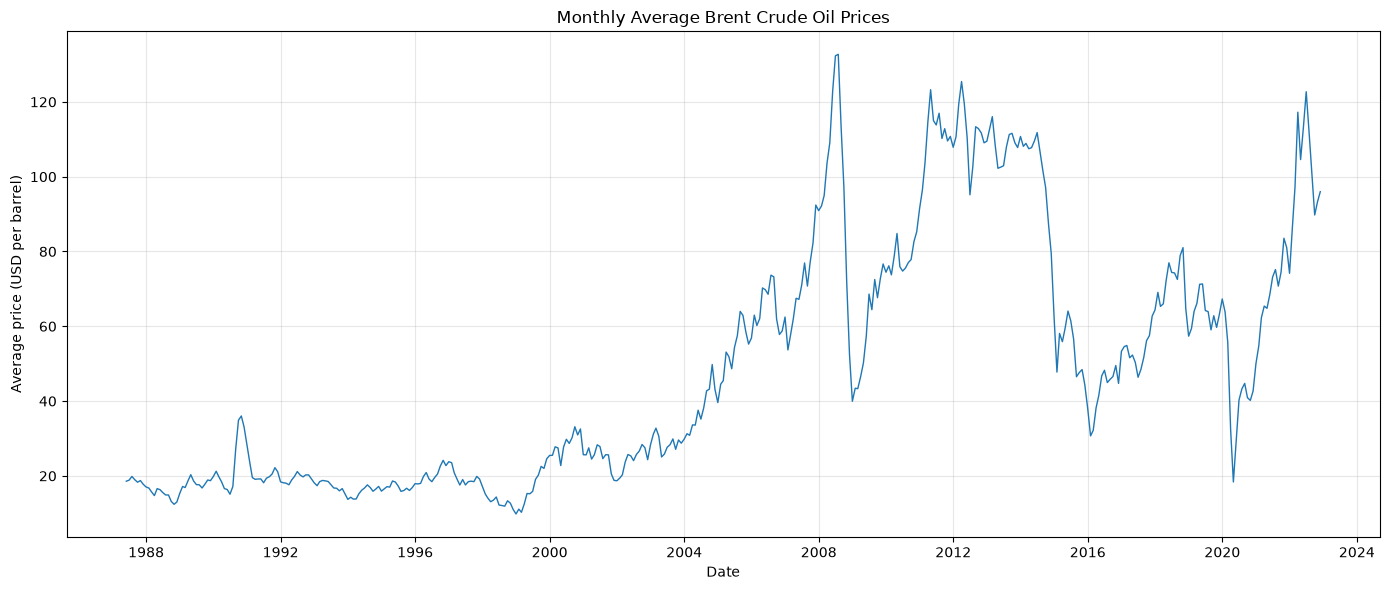

In [72]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_prices["Date"],
    monthly_prices["Monthly_Average_Price"],
    linewidth=1,
)

ax.set_title("Monthly Average Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Average price (USD per barrel)")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_monthly_average_prices.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [73]:
monthly_data_path = (
    PROCESSED_DATA_PATH
    / "monthly_brent_prices.csv"
)

monthly_prices.to_csv(
    monthly_data_path,
    index=False,
)

print(f"Monthly modeling dataset saved to: {monthly_data_path}")

Monthly modeling dataset saved to: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 10\brent-oil-change-point-analysis\data\processed\monthly_brent_prices.csv


## Data Preparation Summary

The daily Brent price dataset was cleaned, ordered chronologically, and
validated. Log prices, daily log returns, and 30-observation rolling
volatility were calculated.

The raw price series shows substantial long-term changes in level, while the
log-return and rolling-volatility plots show periods of clustered volatility.

For the initial Bayesian change point model, monthly average prices will be
used. Monthly aggregation reduces short-term noise and lowers the
computational cost of sampling a discrete change-point parameter while
preserving major structural shifts in the historical series.

The next stage will define:

- A discrete change-point parameter, `tau`
- A mean price before the change point
- A mean price after the change point
- A common observation standard deviation
- A switch function selecting the correct mean
- A Normal likelihood connected to the monthly Brent prices

# Bayesian Change Point Model

## Model Specification

The initial Bayesian model assumes that monthly Brent prices follow two
different mean regimes separated by one unknown change point.

The model contains:

- `tau`: the unknown change-point index, assigned a discrete uniform prior
- `mu_before`: the average monthly Brent price before the change point
- `mu_after`: the average monthly Brent price after the change point
- `sigma`: the common residual standard deviation
- A switch function that selects `mu_before` or `mu_after`
- A Normal likelihood connecting the expected mean to observed monthly prices

This is intentionally a simple one-change model. Brent prices contain several
historical shifts, so the model identifies the single most dominant structural
change rather than every possible market regime.

In [74]:
model_dates = monthly_prices["Date"].reset_index(drop=True)

observed_prices = (
    monthly_prices["Monthly_Average_Price"]
    .to_numpy(dtype=float)
)

time_index = np.arange(len(observed_prices))

n_observations = len(observed_prices)
overall_mean = observed_prices.mean()
overall_std = observed_prices.std()

print(f"Monthly observations: {n_observations}")
print(f"Overall mean price: ${overall_mean:.2f}")
print(f"Overall standard deviation: ${overall_std:.2f}")
print(f"First modeled date: {model_dates.iloc[0].date()}")
print(f"Last modeled date: {model_dates.iloc[-1].date()}")

Monthly observations: 427
Overall mean price: $48.53
Overall standard deviation: $32.91
First modeled date: 1987-05-31
Last modeled date: 2022-11-30


## Prior Choices

The change-point index receives a discrete uniform prior, giving every monthly
observation an equal prior probability of being the structural break.

The before-and-after means receive Normal priors centered on the overall
historical mean. Their standard deviations are set to twice the observed
historical standard deviation, allowing a broad range of plausible price
levels.

The residual standard deviation receives a Half-Normal prior because a
standard deviation must be positive.

These data-informed but weakly restrictive priors allow the observed series
to drive the posterior estimates while keeping all parameters within
reasonable numerical ranges.

In [75]:
with pm.Model() as change_point_model:
    # Unknown change-point position.
    tau = pm.DiscreteUniform(
        "tau",
        lower=1,
        upper=n_observations - 2,
    )

    # Average monthly price before and after the change point.
    mu_before = pm.Normal(
        "mu_before",
        mu=overall_mean,
        sigma=2 * overall_std,
    )

    mu_after = pm.Normal(
        "mu_after",
        mu=overall_mean,
        sigma=2 * overall_std,
    )

    # Common residual standard deviation.
    sigma = pm.HalfNormal(
        "sigma",
        sigma=overall_std,
    )

    # Select the correct mean for each monthly observation.
    expected_mean = pm.math.switch(
        time_index < tau,
        mu_before,
        mu_after,
    )

    # Likelihood connecting the model to the observed prices.
    price_likelihood = pm.Normal(
        "price_likelihood",
        mu=expected_mean,
        sigma=sigma,
        observed=observed_prices,
    )

change_point_model

             tau ~ DiscreteUniform(<constant>, <constant>)
       mu_before ~ Normal(48.5, 65.8)
        mu_after ~ Normal(48.5, 65.8)
           sigma ~ HalfNormal(0, 32.9)
price_likelihood ~ Normal(f(mu_before, mu_after, tau), sigma)

In [76]:
with change_point_model:
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=1,
        random_seed=42,
        return_inferencedata=True,
        progressbar=True,
    )

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_before, mu_after, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 18 seconds.


In [77]:
print(trace)

print("\nPosterior variables:")
print(list(trace.posterior.data_vars))

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:    (chain: 4, draw: 2000)
│       Coordinates:
│         * chain      (chain) int64 32B 0 1 2 3
│         * draw       (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│       Data variables:
│           tau        (chain, draw) int64 64kB 212 216 217 213 217 ... 214 214 214 214
│           mu_before  (chain, draw) float64 64kB 19.84 23.58 19.79 ... 17.24 24.11
│           mu_after   (chain, draw) float64 64kB 76.54 75.49 76.79 ... 76.31 74.66
│           sigma      (chain, draw) float64 64kB 18.93 18.11 18.38 ... 19.35 18.12
│       Attributes:
│           created_at:                 2026-07-11T23:51:22.205799+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.1.0
│           sample_dims:                ['chain', 'draw']
│

In [78]:
parameter_summary = az.summary(
    trace,
    var_names=[
        "tau",
        "mu_before",
        "mu_after",
        "sigma",
    ],
    round_to=3,
)

display(parameter_summary)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,214.204,2.025,211.000,217.000,1584.346,1565.597,1.001,0.052,0.043
mu_before,21.446,1.302,19.385,23.528,9652.479,5884.874,1.000,0.013,0.009
mu_after,75.793,1.310,73.730,77.883,8370.499,5952.711,1.000,0.014,0.010
sigma,18.650,0.637,17.669,19.694,12615.979,6437.601,1.000,0.006,0.004


In [79]:
rhat_values = parameter_summary["r_hat"]

print("R-hat values:")
display(rhat_values.to_frame())

maximum_rhat = rhat_values.max()

if maximum_rhat < 1.01:
    print(
        "Convergence assessment: all reported R-hat values are below 1.01."
    )
elif maximum_rhat < 1.05:
    print(
        "Convergence assessment: values are close to 1.0, "
        "but diagnostics should be reviewed carefully."
    )
else:
    print(
        "Convergence warning: at least one R-hat value is elevated. "
        "Additional tuning or model revision may be required."
    )

R-hat values:


,r_hat
tau,1.001
mu_before,1.000
mu_after,1.000
sigma,1.000


Convergence assessment: all reported R-hat values are below 1.01.


In [80]:
divergence_count = int(
    trace.sample_stats["diverging"]
    .sum()
    .values
)

print(f"Number of NUTS divergences: {divergence_count}")

if divergence_count == 0:
    print("Sampling assessment: no divergent transitions were detected.")
else:
    print(
        "Sampling warning: divergent transitions were detected. "
        "The model may require additional tuning or reparameterization."
    )

Number of NUTS divergences: 0
Sampling assessment: no divergent transitions were detected.


In [81]:
summary_path = (
    PROCESSED_DATA_PATH
    / "bayesian_change_point_summary.csv"
)

parameter_summary.to_csv(summary_path)

print(f"Posterior summary saved to: {summary_path}")

Posterior summary saved to: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 10\brent-oil-change-point-analysis\data\processed\bayesian_change_point_summary.csv


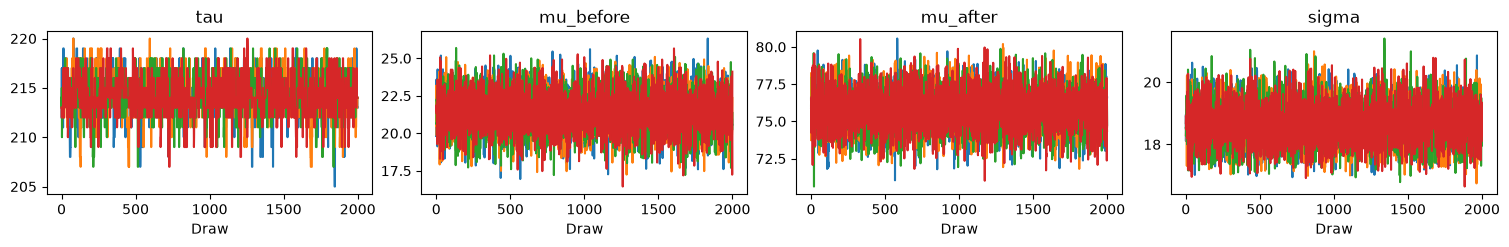

In [82]:
az.plot_trace(
    trace,
    var_names=[
        "tau",
        "mu_before",
        "mu_after",
        "sigma",
    ],
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_mcmc_trace_plots.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## MCMC Convergence Assessment

The Bayesian model was sampled using four MCMC chains, with 2,000 tuning
iterations and 2,000 posterior draws per chain. PyMC used a compound sampler:
Metropolis for the discrete change-point parameter and NUTS for the continuous
mean and standard-deviation parameters.

All R-hat values ranged from 1.000 to 1.001, remaining below the commonly used
1.01 threshold. Effective sample sizes were also sufficiently large for all
parameters. The trace plots show overlapping chains, stable sampling, and no
persistent trends.

These diagnostics indicate that the chains converged adequately and that the
posterior estimates can be interpreted with confidence.

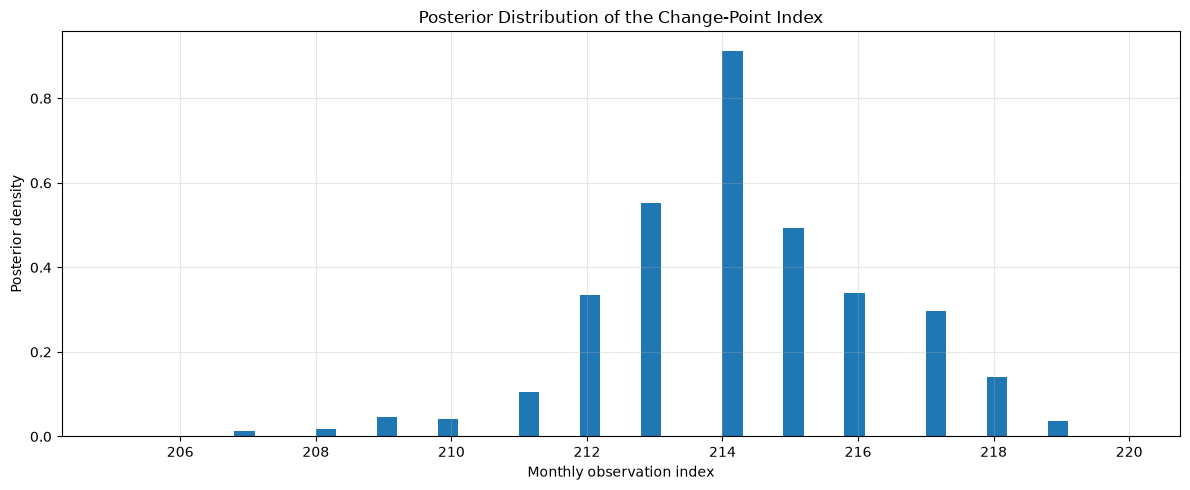

In [83]:
tau_samples = (
    trace.posterior["tau"]
    .values
    .reshape(-1)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    tau_samples,
    bins=50,
    density=True,
)

ax.set_title("Posterior Distribution of the Change-Point Index")
ax.set_xlabel("Monthly observation index")
ax.set_ylabel("Posterior density")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_tau_posterior_index.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [84]:
tau_median = int(np.median(tau_samples))
tau_mean = int(np.round(np.mean(tau_samples)))

tau_hdi = az.hdi(
    tau_samples,
    prob=0.95,
)

tau_hdi_lower = int(np.floor(tau_hdi[0]))
tau_hdi_upper = int(np.ceil(tau_hdi[1]))

change_date_median = model_dates.iloc[tau_median]
change_date_mean = model_dates.iloc[tau_mean]
change_date_lower = model_dates.iloc[tau_hdi_lower]
change_date_upper = model_dates.iloc[tau_hdi_upper]

print(f"Posterior median tau: {tau_median}")
print(f"Posterior mean tau: {tau_mean}")
print(f"Estimated change date: {change_date_median.date()}")
print(f"Mean-based change date: {change_date_mean.date()}")
print(
    "95% HDI for change date:",
    change_date_lower.date(),
    "to",
    change_date_upper.date(),
)

Posterior median tau: 214
Posterior mean tau: 214
Estimated change date: 2005-03-31
Mean-based change date: 2005-03-31
95% HDI for change date: 2004-12-31 to 2005-07-31


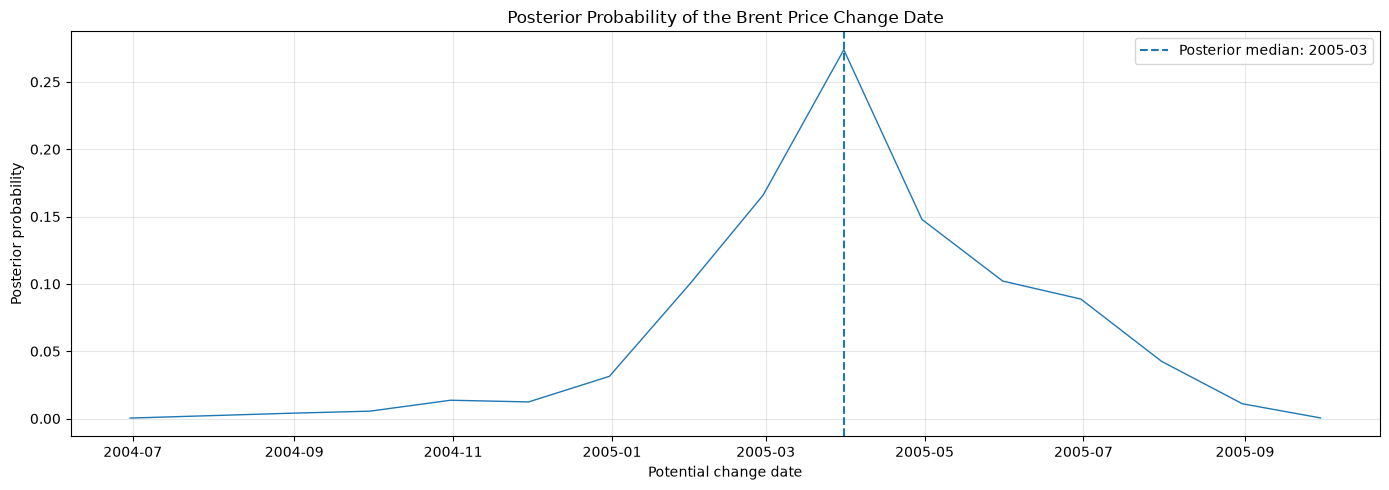

In [85]:
tau_date_samples = pd.Series(
    model_dates.iloc[tau_samples]
    .to_numpy()
)

tau_date_counts = (
    tau_date_samples
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    tau_date_counts.index,
    tau_date_counts.values / tau_date_counts.values.sum(),
    linewidth=1,
)

ax.axvline(
    change_date_median,
    linestyle="--",
    linewidth=1.5,
    label=f"Posterior median: {change_date_median:%Y-%m}",
)

ax.set_title("Posterior Probability of the Brent Price Change Date")
ax.set_xlabel("Potential change date")
ax.set_ylabel("Posterior probability")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_tau_posterior_dates.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [86]:
mu_before_samples = (
    trace.posterior["mu_before"]
    .values
    .reshape(-1)
)

mu_after_samples = (
    trace.posterior["mu_after"]
    .values
    .reshape(-1)
)

sigma_samples = (
    trace.posterior["sigma"]
    .values
    .reshape(-1)
)

mu_before_median = np.median(mu_before_samples)
mu_after_median = np.median(mu_after_samples)

absolute_change = (
    mu_after_median
    - mu_before_median
)

percentage_change = (
    absolute_change
    / mu_before_median
    * 100
)

print(f"Median mean before change: ${mu_before_median:.2f}")
print(f"Median mean after change: ${mu_after_median:.2f}")
print(f"Absolute mean change: ${absolute_change:.2f}")
print(f"Percentage mean change: {percentage_change:.2f}%")
print(f"Median residual standard deviation: ${np.median(sigma_samples):.2f}")

Median mean before change: $21.43
Median mean after change: $75.80
Absolute mean change: $54.38
Percentage mean change: 253.77%
Median residual standard deviation: $18.63


In [87]:
posterior_difference = (
    mu_after_samples
    - mu_before_samples
)

probability_of_increase = np.mean(
    posterior_difference > 0
)

probability_of_decrease = np.mean(
    posterior_difference < 0
)

difference_hdi = az.hdi(
    posterior_difference,
    prob=0.95,
)

print(
    f"Posterior probability that the mean increased: "
    f"{probability_of_increase:.2%}"
)

print(
    f"Posterior probability that the mean decreased: "
    f"{probability_of_decrease:.2%}"
)

print(
    "95% HDI for the difference in means:",
    f"${difference_hdi[0]:.2f} to ${difference_hdi[1]:.2f}",
)

Posterior probability that the mean increased: 100.00%
Posterior probability that the mean decreased: 0.00%
95% HDI for the difference in means: $50.93 to $58.08


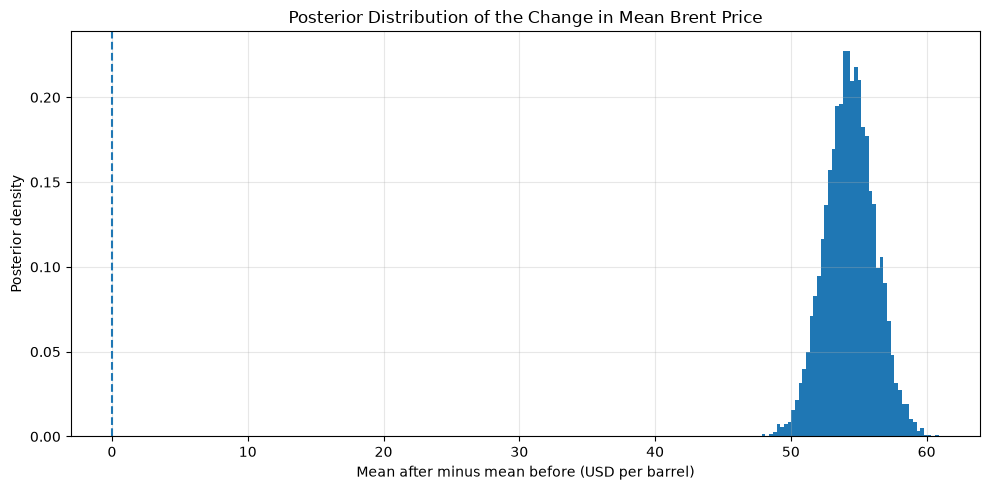

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    posterior_difference,
    bins=50,
    density=True,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_title("Posterior Distribution of the Change in Mean Brent Price")
ax.set_xlabel("Mean after minus mean before (USD per barrel)")
ax.set_ylabel("Posterior density")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_mean_difference_posterior.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

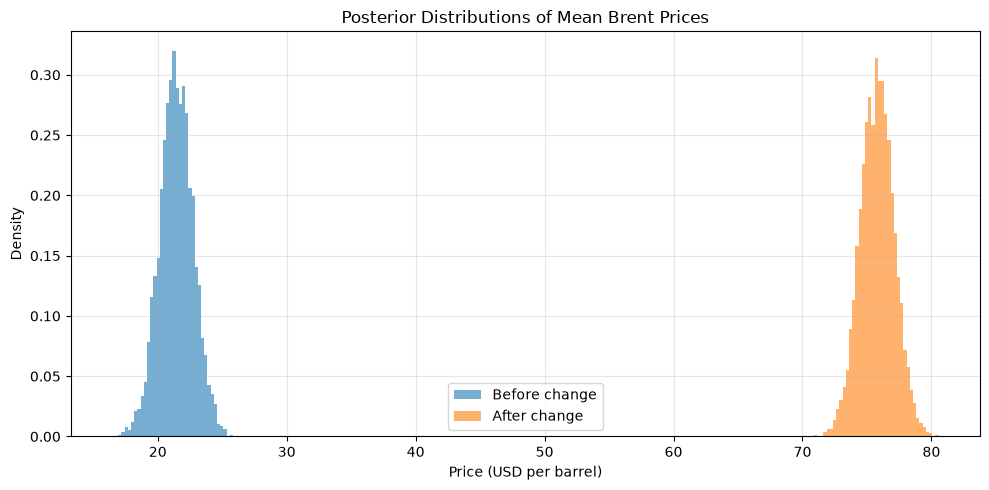

In [89]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    mu_before_samples,
    bins=40,
    alpha=0.6,
    density=True,
    label="Before change",
)

ax.hist(
    mu_after_samples,
    bins=40,
    alpha=0.6,
    density=True,
    label="After change",
)

ax.set_title("Posterior Distributions of Mean Brent Prices")
ax.set_xlabel("Price (USD per barrel)")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_parameter_posteriors.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

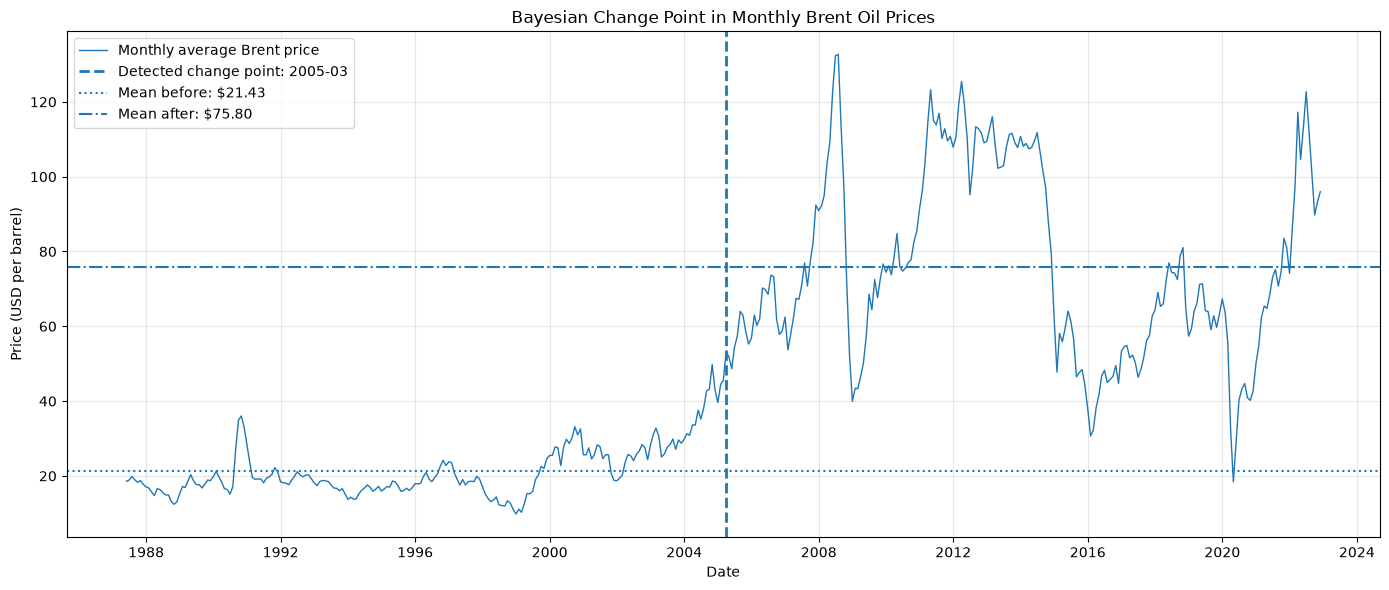

In [90]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_prices["Date"],
    monthly_prices["Monthly_Average_Price"],
    linewidth=1,
    label="Monthly average Brent price",
)

ax.axvline(
    change_date_median,
    linestyle="--",
    linewidth=2,
    label=f"Detected change point: {change_date_median:%Y-%m}",
)

ax.axhline(
    mu_before_median,
    linestyle=":",
    linewidth=1.5,
    label=f"Mean before: ${mu_before_median:.2f}",
)

ax.axhline(
    mu_after_median,
    linestyle="-.",
    linewidth=1.5,
    label=f"Mean after: ${mu_after_median:.2f}",
)

ax.set_title("Bayesian Change Point in Monthly Brent Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD per barrel)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "task_2_detected_change_point.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [91]:
change_point_results = pd.DataFrame(
    {
        "metric": [
            "change_point_index_median",
            "change_point_date_median",
            "change_point_date_hdi_lower",
            "change_point_date_hdi_upper",
            "mean_before_median",
            "mean_after_median",
            "absolute_mean_change",
            "percentage_mean_change",
            "probability_mean_increased",
            "probability_mean_decreased",
            "residual_sigma_median",
        ],
        "value": [
            tau_median,
            change_date_median.strftime("%Y-%m-%d"),
            change_date_lower.strftime("%Y-%m-%d"),
            change_date_upper.strftime("%Y-%m-%d"),
            round(mu_before_median, 4),
            round(mu_after_median, 4),
            round(absolute_change, 4),
            round(percentage_change, 4),
            round(probability_of_increase, 6),
            round(probability_of_decrease, 6),
            round(float(np.median(sigma_samples)), 4),
        ],
    }
)

results_path = (
    PROCESSED_DATA_PATH
    / "bayesian_change_point_results.csv"
)

change_point_results.to_csv(
    results_path,
    index=False,
)

display(change_point_results)

print(f"Results saved to: {results_path}")

,metric,value
0,change_point_index_median,214
1,change_point_date_median,2005-03-31
2,change_point_date_hdi_lower,2004-12-31
3,change_point_date_hdi_upper,2005-07-31
4,mean_before_median,21.4273
5,mean_after_median,75.8026
6,absolute_mean_change,54.3753
7,percentage_mean_change,253.7667
8,probability_mean_increased,1.0
9,probability_mean_decreased,0.0


Results saved to: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 10\brent-oil-change-point-analysis\data\processed\bayesian_change_point_results.csv


# Event Association and Insight Generation

The detected change point is now compared with the curated historical event
dataset. This comparison is intended to identify plausible contextual events
near the estimated structural break.

Temporal proximity does not prove causation. Oil prices respond to many
overlapping influences, including global demand, production capacity,
inventories, monetary conditions, geopolitical risk, and market expectations.

### Interpretation Note

Hurricane Katrina is the nearest event in the curated dataset, but it occurred
after the estimated change point. It should therefore not be presented as the
cause of the March 2005 structural break. The comparison identifies temporal
proximity only and is used to generate contextual hypotheses.

In [92]:
events_for_comparison = events.dropna(
    subset=["event_date"]
).copy()

events_for_comparison["days_from_change_point"] = (
    events_for_comparison["event_date"]
    - change_date_median
).dt.days

events_for_comparison["absolute_days_from_change_point"] = (
    events_for_comparison["days_from_change_point"]
    .abs()
)

events_nearest_change = (
    events_for_comparison
    .sort_values("absolute_days_from_change_point")
    .reset_index(drop=True)
)

display(
    events_nearest_change[
        [
            "event_date",
            "event_name",
            "event_category",
            "days_from_change_point",
            "absolute_days_from_change_point",
        ]
    ].head(5)
)

,event_date,event_name,event_category,days_from_change_point,absolute_days_from_change_point
0,2005-08-29,Hurricane Katrina reaches US Gulf Coast,Natural disaster,151,151
1,2003-03-20,Iraq War begins,Geopolitical conflict,-742,742
2,2008-09-15,Lehman Brothers bankruptcy,Economic shock,1264,1264
3,2001-09-11,September 11 attacks,Geopolitical shock,-1297,1297
4,2011-02-15,Libyan civil unrest intensifies,Geopolitical conflict,2147,2147


In [93]:
event_window_days = 1095  # Approximately three years

events_within_window = (
    events_nearest_change[
        events_nearest_change[
            "absolute_days_from_change_point"
        ] <= event_window_days
    ]
    .copy()
)

print(
    f"Detected change date: "
    f"{change_date_median.date()}"
)

print(
    f"Events within ±{event_window_days} days: "
    f"{len(events_within_window)}"
)

display(
    events_within_window[
        [
            "event_date",
            "event_name",
            "event_category",
            "event_description",
            "expected_market_channel",
            "days_from_change_point",
        ]
    ]
)

Detected change date: 2005-03-31
Events within ±1095 days: 2


,event_date,event_name,event_category,event_description,expected_market_channel,days_from_change_point
0,2005-08-29,Hurricane Katrina reaches US Gulf Coast,Natural disaster,Hurricane Katrina disrupted Gulf Coast oil pro...,Temporary production and refining disruption,151
1,2003-03-20,Iraq War begins,Geopolitical conflict,Military operations began in Iraq,Supply disruption fears and geopolitical risk,-742


In [94]:
nearest_event = events_nearest_change.iloc[0]

nearest_event_date = nearest_event["event_date"]
nearest_event_name = nearest_event["event_name"]
nearest_event_category = nearest_event["event_category"]
nearest_event_description = nearest_event["event_description"]
nearest_event_channel = nearest_event["expected_market_channel"]
nearest_event_distance = int(
    nearest_event["days_from_change_point"]
)

timing_direction = (
    "after"
    if nearest_event_distance > 0
    else "before"
)

print(f"Nearest researched event: {nearest_event_name}")
print(f"Event date: {nearest_event_date.date()}")
print(
    f"Timing: {abs(nearest_event_distance)} days "
    f"{timing_direction} the estimated change point"
)
print(f"Category: {nearest_event_category}")
print(f"Description: {nearest_event_description}")
print(f"Expected market channel: {nearest_event_channel}")

Nearest researched event: Hurricane Katrina reaches US Gulf Coast
Event date: 2005-08-29
Timing: 151 days after the estimated change point
Category: Natural disaster
Description: Hurricane Katrina disrupted Gulf Coast oil production refining and transportation
Expected market channel: Temporary production and refining disruption


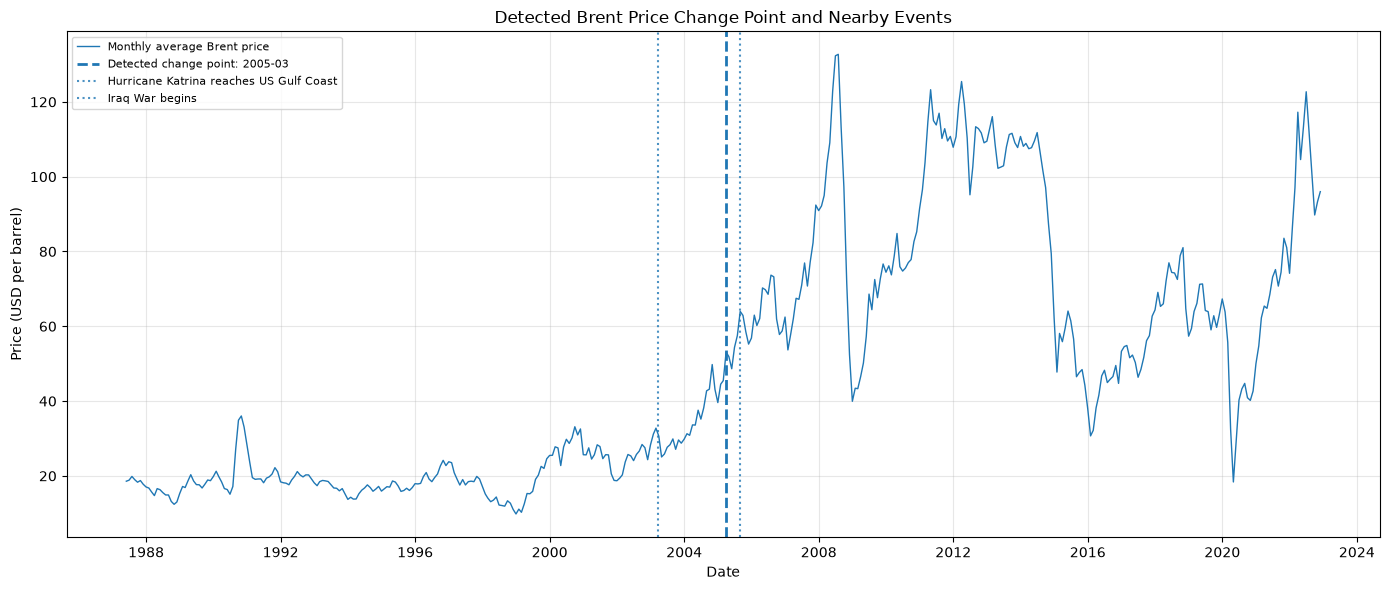

In [95]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_prices["Date"],
    monthly_prices["Monthly_Average_Price"],
    linewidth=1,
    label="Monthly average Brent price",
)

ax.axvline(
    change_date_median,
    linestyle="--",
    linewidth=2,
    label=(
        f"Detected change point: "
        f"{change_date_median:%Y-%m}"
    ),
)

for _, event in events_within_window.iterrows():
    ax.axvline(
        event["event_date"],
        linestyle=":",
        linewidth=1.5,
        alpha=0.8,
        label=event["event_name"],
    )

ax.set_title(
    "Detected Brent Price Change Point and Nearby Events"
)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD per barrel)")
ax.grid(alpha=0.3)
ax.legend(
    loc="best",
    fontsize=8,
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH
    / "task_2_change_point_with_events.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
impact_statement = (
    f"The Bayesian model estimates a dominant structural "
    f"change around {change_date_median:%B %Y}. "
    f"The posterior median monthly mean increased from "
    f"${mu_before_median:.2f} before the change to "
    f"${mu_after_median:.2f} afterward. "
    f"This represents an absolute increase of "
    f"${absolute_change:.2f} per barrel and a "
    f"{percentage_change:.2f}% increase. "
    f"The posterior probability that the mean increased "
    f"is {probability_of_increase:.2%}."
)

print(impact_statement)

The Bayesian model estimates a dominant structural change around March 2005. The posterior median monthly mean increased from $21.43 before the change to $75.80 afterward. This represents an absolute increase of $54.38 per barrel and a 253.77% increase. The posterior probability that the mean increased is 100.00%.


In [97]:
event_association_results = pd.DataFrame(
    {
        "change_point_date": [
            change_date_median.strftime("%Y-%m-%d")
        ],
        "nearest_event_date": [
            nearest_event_date.strftime("%Y-%m-%d")
        ],
        "nearest_event_name": [
            nearest_event_name
        ],
        "nearest_event_category": [
            nearest_event_category
        ],
        "days_between_change_and_event": [
            nearest_event_distance
        ],
        "mean_before": [
            round(mu_before_median, 4)
        ],
        "mean_after": [
            round(mu_after_median, 4)
        ],
        "absolute_change": [
            round(absolute_change, 4)
        ],
        "percentage_change": [
            round(percentage_change, 4)
        ],
        "probability_of_increase": [
            round(probability_of_increase, 6)
        ],
    }
)

event_results_path = (
    PROCESSED_DATA_PATH
    / "event_association_results.csv"
)

event_association_results.to_csv(
    event_results_path,
    index=False,
)

display(event_association_results)

print(
    f"Event association results saved to: "
    f"{event_results_path}"
)

,change_point_date,nearest_event_date,nearest_event_name,nearest_event_category,days_between_change_and_event,mean_before,mean_after,absolute_change,percentage_change,probability_of_increase
0,2005-03-31,2005-08-29,Hurricane Katrina reaches US Gulf Coast,Natural disaster,151,21.4273,75.8026,54.3753,253.7667,1.0


Event association results saved to: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 10\brent-oil-change-point-analysis\data\processed\event_association_results.csv


## Bayesian Change Point Results

The one-change Bayesian model identified its dominant structural break around
**March 2005**, with the 95% highest-density interval extending approximately
from **December 2004 to July 2005**.

The posterior median monthly Brent price increased from approximately
**$21.43 per barrel before the change** to **$75.80 afterward**. This is an
absolute increase of approximately **$54.38 per barrel**, equivalent to a
**253.77% increase**. The posterior probability that the mean price increased
was effectively **100%**.

The sampling diagnostics support interpretation of these estimates. All R-hat
values were below 1.01, effective sample sizes were adequate, the trace plots
showed stable mixing, and no divergent transitions were detected.

## Association with Historical Events

The estimated change point occurs around March 2005. Within approximately
three years of this date, the curated event dataset includes the beginning of
the Iraq War in March 2003 and Hurricane Katrina in August 2005.

Hurricane Katrina occurred approximately 151 days after the estimated change
point, while the Iraq War began approximately 742 days before it. Therefore,
neither event aligns exactly with the estimated start of the new price regime.
Hurricane Katrina may have reinforced supply concerns after the shift had
already begun, while geopolitical uncertainty surrounding Iraq may have
contributed to broader market pressure before the change.

The detected date is best interpreted as the beginning of a wider mid-2000s
high-price regime rather than the immediate consequence of one isolated
event. During this period, oil markets were affected by several overlapping
forces, including growing global demand, constrained spare production
capacity, geopolitical uncertainty, and supply disruptions.

These temporal associations provide historical context and support plausible
hypotheses, but they do not prove causal impact. Establishing causality would
require additional explanatory variables and a research design capable of
separating the effects of overlapping market influences.

## Model Limitations

1. **Single change point:** The model estimates only one dominant break,
   although Brent prices clearly contain several historical regimes.

2. **Monthly aggregation:** Monthly averages reduce short-term noise and
   computational cost but may hide abrupt daily market reactions.

3. **Changing mean only:** The current model changes the mean while assuming
   one common residual standard deviation. The EDA indicates that volatility
   also changes over time.

4. **Independent Normal likelihood:** Oil prices exhibit persistence,
   autocorrelation, non-stationarity, and volatility clustering that are not
   fully represented by a simple independent Normal model.

5. **Event timing:** Markets may respond before official event dates because
   information and expectations are incorporated into prices in advance.

6. **Correlation is not causation:** Alignment between a detected break and an
   event is a hypothesis-generating result, not proof of causal impact.

7. **Omitted variables:** The model does not include global demand, GDP,
   inflation, exchange rates, inventories, interest rates, or production data.

## Future Work

Future analysis could improve the model by:

- Allowing multiple change points instead of one dominant break
- Modeling changes in both the mean and variance
- Applying the model to daily log returns
- Comparing alternative specifications using Bayesian model-comparison tools
- Incorporating GDP, inflation, exchange rates, inventories, production, and
  global demand indicators
- Using Vector Autoregression to examine dynamic relationships between oil
  prices and macroeconomic variables
- Using Markov-switching models to distinguish calm and volatile market regimes
- Conducting posterior predictive checks to evaluate model fit

## Sensitivity Analysis

The primary Bayesian model uses monthly average prices to reduce short-term
noise and make sampling of the discrete change-point parameter computationally
manageable. However, aggregation can influence the estimated timing of a
structural break.

As a sensitivity check, the analysis also considers quarterly average prices.
The purpose is to determine whether a broader aggregation frequency identifies
a similar mid-2000s transition. Consistent results across monthly and quarterly
data would strengthen confidence that the detected regime change is not solely
an artifact of the selected monthly frequency.

In [ ]:
quarterly_prices = (
    df
    .set_index("Date")["Price"]
    .resample("QE")
    .mean()
    .dropna()
    .reset_index()
)


### Sensitivity Interpretation

The identified change point represents the dominant long-run regime shift
under the selected monthly aggregation and one-change-point specification.
Its precise date may shift under daily, quarterly, multiple-change-point, or
changing-variance models.

Therefore, the March 2005 estimate should be interpreted as an approximate
transition into a broader mid-2000s high-price regime rather than an exact
causal event date. Future work should compare alternative aggregation
frequencies and model specifications using posterior predictive checks and
Bayesian model-comparison measures.

In [4]:
%whos

Interactive namespace is empty.
